In [17]:
import pandas as pd
from CBFV import composition
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score,roc_curve

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from matminer.featurizers.composition import ElementProperty
from pymatgen.core.composition import Composition

In [23]:
# read the data
df = pd.read_csv('C:\\Users\\18245\\Desktop\\pythontest\\assignment2\\Assign_classification_data.csv')
print(df.head(),"\n")
print(f"shape of df:{df.shape}","\n")

print(df.isnull().sum(),"\n")
df1=df.dropna()
print(f"shape of df1:{df1.shape}","\n")


    composition  Eg (eV)
0  Hg0.7Cd0.3Te     0.35
1          CuBr     3.08
2           LuP     1.30
3      Cu3SbSe4     0.40
4           ZnO     3.44 

shape of df:(6367, 2) 

composition    1
Eg (eV)        8
dtype: int64 

shape of df1:(6358, 2) 



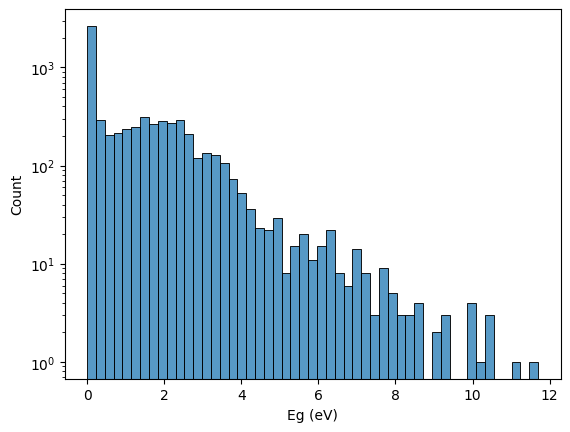

           Eg (eV)     is_metal
count  6354.000000  6354.000000
mean      1.252262     0.469940
std       1.539963     0.499135
min       0.000000     0.000000
25%       0.000000     0.000000
50%       0.710000     0.000000
75%       2.130000     1.000000
max      11.700000     1.000000


In [ ]:
#showing the distribution of Eg (eV)
sns.histplot(df1['Eg (eV)'])
plt.yscale('log')#using log scale for better visualization
plt.xlabel('Eg (eV)')
plt.show()

print(df1.describe())

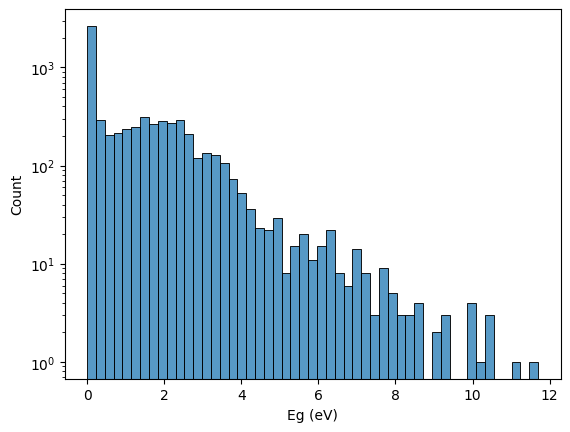

           Eg (eV)     is_metal
count  6354.000000  6354.000000
mean      1.252262     0.469940
std       1.539963     0.499135
min       0.000000     0.000000
25%       0.000000     0.000000
50%       0.710000     0.000000
75%       2.130000     1.000000
max      11.700000     1.000000


In [28]:
#delete the negative values in Eg (eV) column
df1 = df1[df1['Eg (eV)'] >= 0]
sns.histplot(df1['Eg (eV)'])
plt.yscale('log')
plt.xlabel('Eg (eV)')
plt.show()
print(df1.describe())

    composition  Eg (eV)  is_metal
0  Hg0.7Cd0.3Te     0.35         1
1          CuBr     3.08         0
2           LuP     1.30         0
3      Cu3SbSe4     0.40         1
4           ZnO     3.44         0


C:\Users\18245\AppData\Local\Temp\ipykernel_28232\1101191939.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_metal', data=df1, palette='Set2', width=0.6)


<Axes: xlabel='is_metal', ylabel='count'>

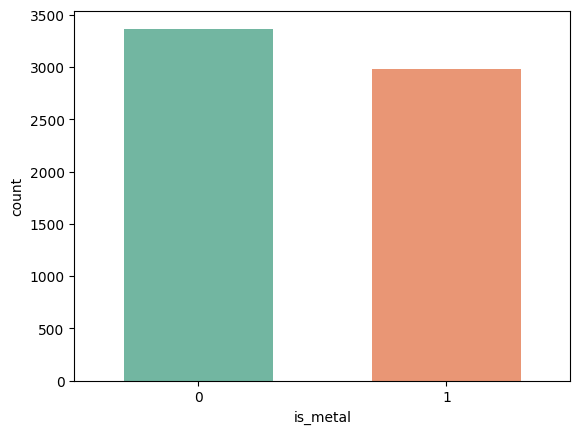

In [30]:
#assuming that Eg(eV)> threshold is metal, else is non-metal
threshold=0.5
df1["is_metal"]=(df1["Eg (eV)"]<=threshold).astype(int)
print(df1.head())
#visualizing the distribution of metals and non-metals
sns.countplot(x='is_metal', data=df1, palette='Set2', width=0.6)

In [ ]:
#feature extraction using matminer
#this will take some time,plz do not run it
df1["composition"] = df1["composition"].apply(Composition)
ep_feat = ElementProperty.from_preset(preset_name="magpie")
features_df = ep_feat.featurize_dataframe(df1, col_id="composition")
print(features_df.head())
#save_path can be modified as needed
features_df.to_csv("C:\\Users\\18245\\Desktop\\pythontest\\assignment2\\features_df.csv")

d:\pythonAI\anaconda3\envs\pytorch\Lib\site-packages\matminer\utils\data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)
ElementProperty:   3%|▎         | 220/6354 [00:10<03:28, 29.42it/s]

In [ ]:
#read the feature data
newdata=pd.read_csv("C:\\Users\\18245\\Desktop\\pythontest\\assignment2\\features_df.csv")
newdata.head()

,Unnamed: 0,composition,Eg (eV),is_metal,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,0,Hg0.7 Cd0.3 Te1,0.35,1,48.0,80.0,32.0,61.20,13.1600,52.0,...,0.000000,0.000000,0.000000,0.0,152.0,194.0,42.0,163.200,11.200,152.0
1,1,Cu1 Br1,3.08,0,29.0,35.0,6.0,32.00,3.0000,29.0,...,0.000000,0.000000,0.000000,0.0,64.0,225.0,161.0,144.500,80.500,64.0
2,2,Lu1 P1,1.30,0,15.0,71.0,56.0,43.00,28.0000,15.0,...,0.002247,0.001124,0.001124,0.0,2.0,194.0,192.0,98.000,96.000,2.0
3,3,Cu3 Sb1 Se4,0.40,1,29.0,51.0,22.0,34.25,4.1875,34.0,...,0.000000,0.000000,0.000000,0.0,14.0,225.0,211.0,112.125,98.125,14.0
4,4,Zn1 O1,3.44,0,8.0,30.0,22.0,19.00,11.0000,8.0,...,0.000000,0.000000,0.000000,0.0,12.0,194.0,182.0,103.000,91.000,12.0


In [31]:
#drop unnecessary columns and bulid X and y
X=newdata.drop(columns=["Unnamed: 0","composition","Eg (eV)","is_metal"])
y=newdata["is_metal"]
X.head()

,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,MagpieData mean MendeleevNumber,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,48.0,80.0,32.0,61.20,13.1600,52.0,70.0,90.0,20.0,80.350,...,0.000000,0.000000,0.000000,0.0,152.0,194.0,42.0,163.200,11.200,152.0
1,29.0,35.0,6.0,32.00,3.0000,29.0,64.0,95.0,31.0,79.500,...,0.000000,0.000000,0.000000,0.0,64.0,225.0,161.0,144.500,80.500,64.0
2,15.0,71.0,56.0,43.00,28.0000,15.0,41.0,83.0,42.0,62.000,...,0.002247,0.001124,0.001124,0.0,2.0,194.0,192.0,98.000,96.000,2.0
3,29.0,51.0,22.0,34.25,4.1875,34.0,64.0,89.0,25.0,79.125,...,0.000000,0.000000,0.000000,0.0,14.0,225.0,211.0,112.125,98.125,14.0
4,8.0,30.0,22.0,19.00,11.0000,8.0,69.0,87.0,18.0,78.000,...,0.000000,0.000000,0.000000,0.0,12.0,194.0,182.0,103.000,91.000,12.0


In [32]:
from collections import Counter
#count the distribution of y
print(Counter(y))

Counter({0: 3368, 1: 2986})


In [34]:
#split the data into train and test sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [35]:
rf_classifier=RandomForestClassifier(class_weight="balanced",
                                     random_state=34,
                                     n_jobs=-1,#use all the cores
                                     n_estimators=100)

In [36]:
rf_classifier.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Accuracy: 0.9291896144767899
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       674
           1       0.93      0.91      0.92       597

    accuracy                           0.93      1271
   macro avg       0.93      0.93      0.93      1271
weighted avg       0.93      0.93      0.93      1271



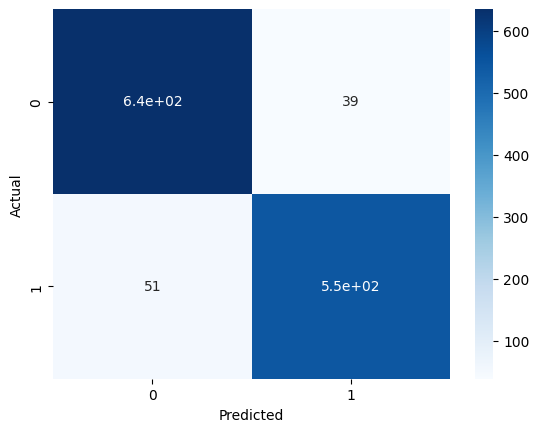

ROC AUC: 0.9781834493933564


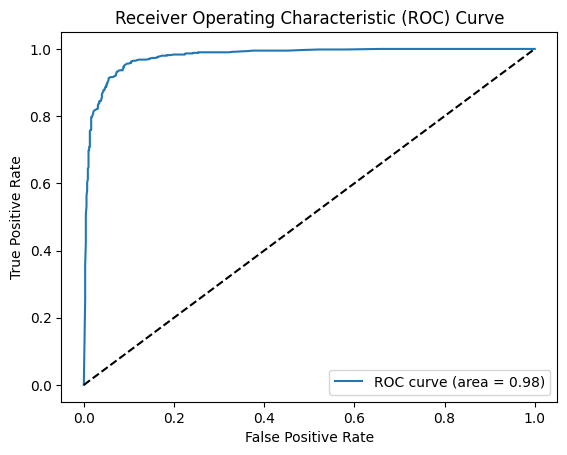

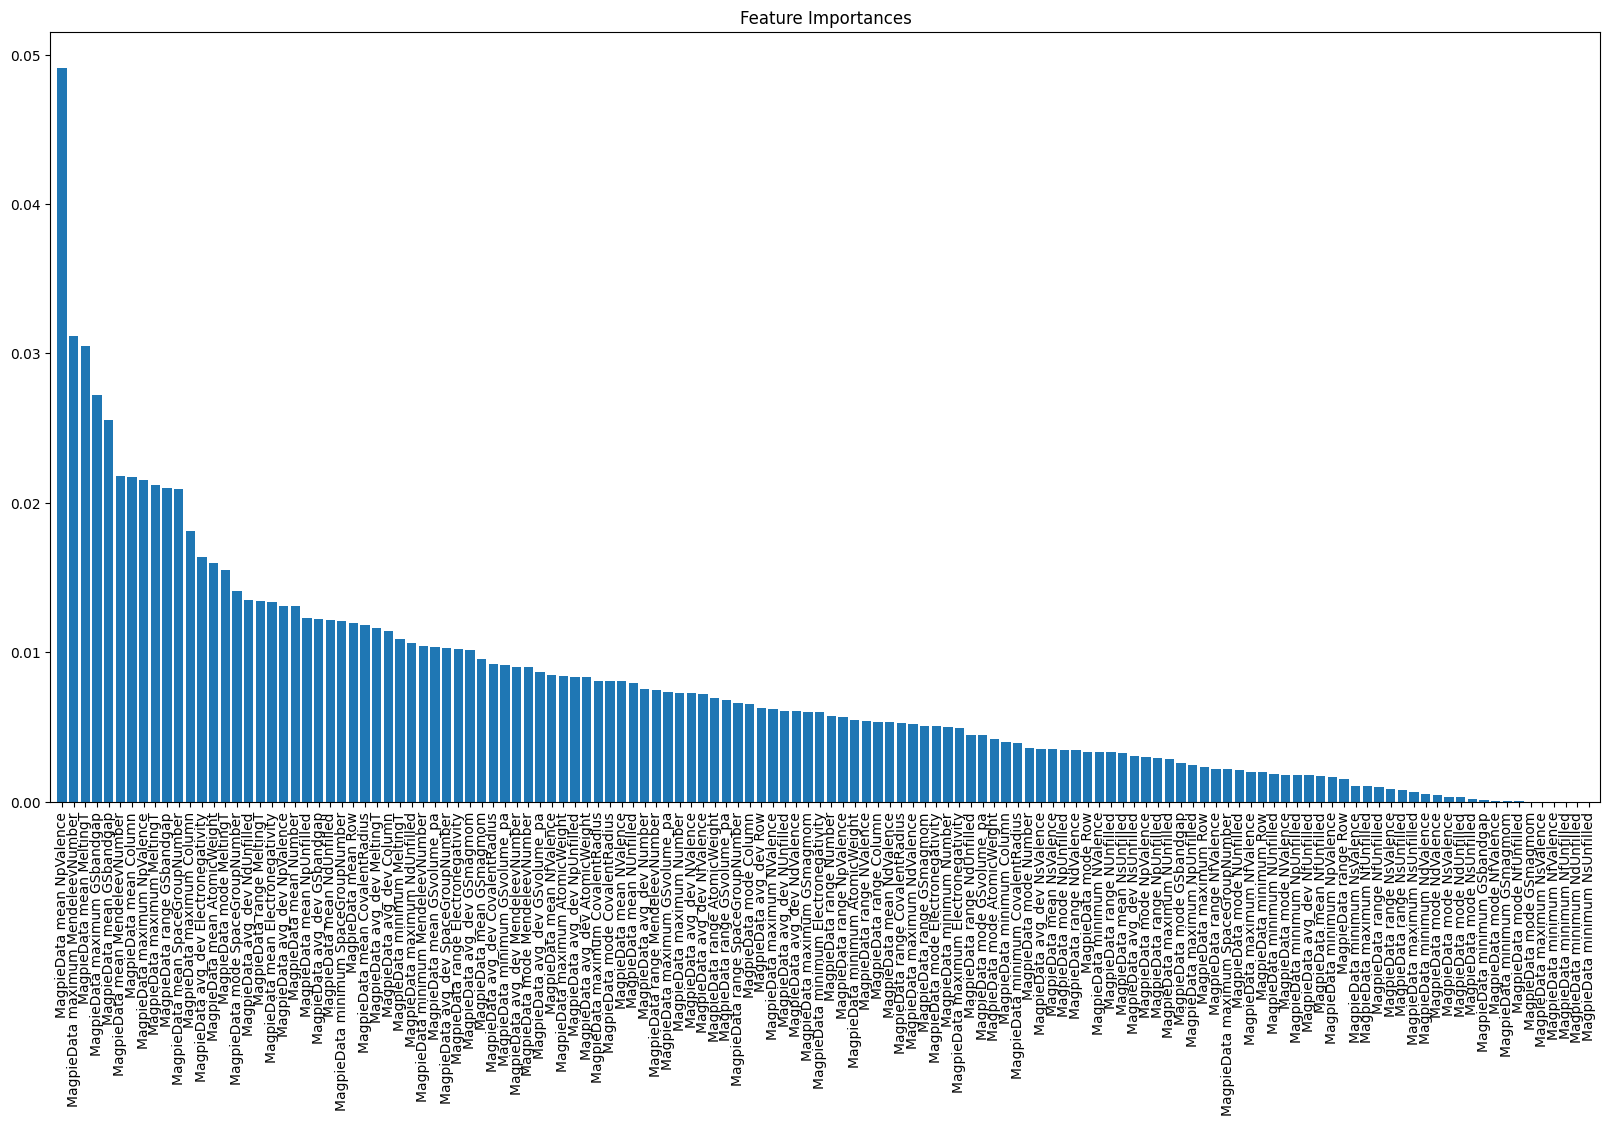

In [37]:
# quantify the performance of the classifier.
y_pred=rf_classifier.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
y_prob=rf_classifier.predict_proba(X_test)[:, 1]
roc_auc=roc_auc_score(y_test, y_prob)
print("ROC AUC:", roc_auc)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.Figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()
importances = rf_classifier.feature_importances_
indices=np.argsort(importances)[::-1]
feature_names=X.columns
plt.figure(figsize=(20,10))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.show()

In [39]:
#this part will implement the hyperparameter tuning using RandomizedSearchCV

param_dist = {
    'n_estimators': np.arange(50, 150, 10),
    'max_depth': [None] + list(np.arange(5, 30, 5)),
    'min_samples_split': np.arange(2, 20, 2),
    'min_samples_leaf': np.arange(1, 10, 1),
    'max_features': ['sqrt', 'log2']
}
rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,  # search 50 different combinations
    cv=5,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
print("best parameters:", random_search.best_params_)

# using the besdt estimator to make predictions
rf_best = random_search.best_estimator_
y_pred_best = rf_best.predict(X_test)
print("Optimized model accuracy:", accuracy_score(y_test, y_pred_best))


best parameters: {'n_estimators': 140, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': None}
Optimized model accuracy: 0.9276160503540519


Accuracy: 0.9291896144767899
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       674
           1       0.93      0.91      0.92       597

    accuracy                           0.93      1271
   macro avg       0.93      0.93      0.93      1271
weighted avg       0.93      0.93      0.93      1271



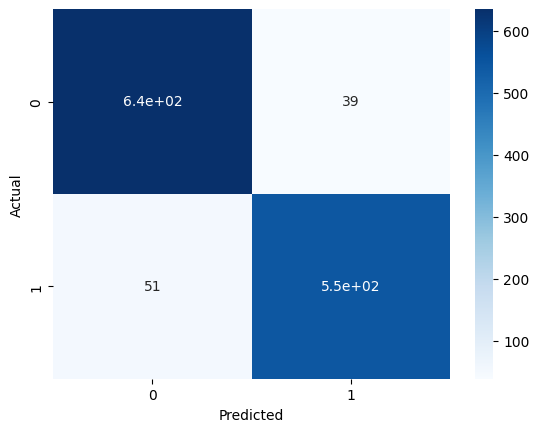

ROC AUC: 0.9781834493933564


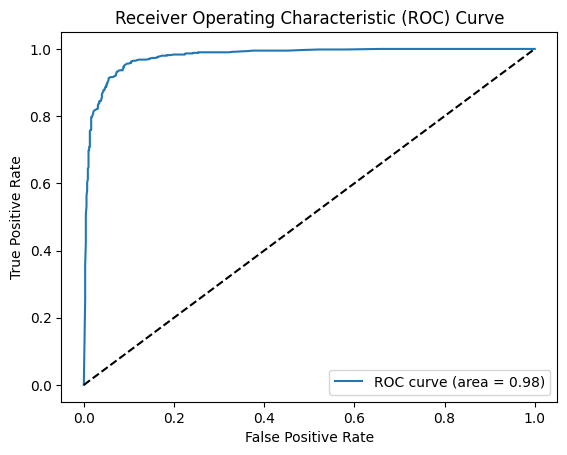

In [40]:
# quantify the performance of the classifier.
y_pred_best=rf_classifier.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
cm=confusion_matrix(y_test,y_pred_best)
sns.heatmap(cm, annot=True, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
y_prob_2=rf_classifier.predict_proba(X_test)[:, 1]
roc_auc=roc_auc_score(y_test, y_prob_2)
print("ROC AUC:", roc_auc)
fpr, tpr, thresholds = roc_curve(y_test, y_prob_2)
plt.Figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:

"""
comment of the model:
In this assignment, Random Forest Classifier is trained to predict whether a material is a metal or not based on its features.
The influence of hyperparameter tuning on model performance is evaluated, and the results shows that the optimized model does not significantly outperform the default model.
The overall performance of the model is outstanding, especially with a ROC AUC close to 0.98, indicating that the classification boundary is very clear.
The only area for improvement is the recall rate for class 1 (0.91).
This can be improved by
- Adjusting class_weight or using threshold tuning to increase the recall rate.
- Or trying ensemble methods (such as XGBoost, LightGBM) to further improve performance.

"""
